# Dimensionality Reduction 

(See [wikipedia article](https://en.wikipedia.org/wiki/Dimensionality_reduction))

High-dimensional datasets—those with a vast number of features—often suffer from the "curse of dimensionality" where data becomes sparse, computational costs skyrocket, and model performance degrades. Dimensionality reduction is critical because it addresses these challenges in several ways: 
1. Improves Computational Efficiency: By reducing the number of features, algorithms require less memory and processing power, leading to faster training times and quicker data retrieval.
1. Prevents Overfitting: Models trained on too many features—especially redundant or noisy ones—often learn to "memorize" the training data rather than generalize. Simplifying the feature space helps models perform better on new, unseen data.
1. Enhances Data Visualization: Humans cannot easily interpret data beyond three dimensions. Techniques like PCA or t-SNE transform complex data into 2D or 3D formats, allowing analysts to spot clusters, trends, and relationships that would otherwise be hidden.
1. Simplifies Data Management: Reducing the size of datasets improves storage efficiency and streamlines data pipelines, making it easier to maintain high-quality, actionable data. 

Common Technqiues includes principle componnent analysis (discussed here), [auto-encoders](https://en.wikipedia.org/wiki/Autoencoder) (a atrificual nural network method), and a variety of other methods.  We will focus on PCA since it is a good example, but consider other techniques in your research as necessary.


## Principle Component Analysis 

[Principal Component Analysis](https://en.wikipedia.org/wiki/Principal_component_analysis) or PCA is a method where sets of data are compressed by identifying the modes with the highest degree of correlation between the sets.   Examples include sets of spectra of similar objects, or the spatial patterns of atompsheric flucuations across astronomical detector arrays.   This is related to the [Signular Value Decomposition](https://en.wikipedia.org/wiki/Singular_value_decomposition) which is a method for decomposing a matrix into a new orothonormal basis with directions ranked for the largest dispersion.   PCA is a key technique for dimensionality reduction since it facilitates keeping only the bassis vectors with the highest variance and rejecting the rest leading to massive compressions. 

Singular Value Decomposition (SVD) is a matrix factorization method in linear algebra that decomposes any $m \times n$ matrix A into three constituent matrices: 
$A = U \Sigma V^T$  It is widely considered one of the most powerful tools in data science, providing a way to identify patterns, reduce dimensionality, and compress data.

The decomposition breaks a matrix into three specific parts: 

1. ($U$ Left Singular Vectors): An $m×m$ orthogonal matrix where columns represent the output directions of the transformation.
1. ($\Sigma$ Singular Values): An $m \times n$ diagonal matrix containing non-negative real numbers (singular values) in descending order. These values represent the "strength" or importance of each corresponding dimension.
1.  ($V^T$ Right Singular Vectors): The transpose of an $n \times n$ orthogonal matrix where rows represent the input directions.

These steps represent a rotation followed by a scaling, and a final rotation or reflection.  The dimeisonailt reduciton is an additional step where the lower rank singular values are thrown out.  This is what makes the compression possible.




 

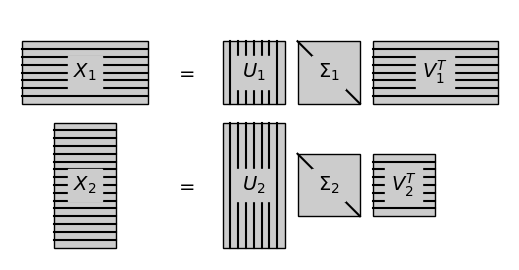

In [2]:
# Author: Jake VanderPlas
# License: BSD
#   The figure produced by this code is published in the textbook
#   "Statistics, Data Mining, and Machine Learning in Astronomy" (2013)
#   For more information, see http://astroML.github.com
#   To report a bug or issue, use the following forum:
#    https://groups.google.com/forum/#!forum/astroml-general
import numpy as np
from matplotlib import pyplot as plt
from matplotlib.patches import Rectangle

#----------------------------------------------------------------------
# This function adjusts matplotlib settings for a uniform feel in the textbook.
# Note that with usetex=True, fonts are rendered with LaTeX.  This may
# result in an error if LaTeX is not installed on your system.  In that case,
# you can set usetex to False.
#if "setup_text_plots" not in globals():
#    from astroML.plotting import setup_text_plots
#setup_text_plots(fontsize=8, usetex=True)


# Define a function to create a rectangle
def labeled_rect(ax, center, width, height, text,
                 stripe='vert', N=7, color='#CCCCCC'):
    left = center[0] - 0.5 * width
    bottom = center[1] - 0.5 * height
    ax.add_patch(Rectangle((left, bottom), width, height,
                           fill=True, color=color, ec='k'))
    ax.text(center[0], center[1], text,
            fontsize=14, ha='center', va='center',
            bbox=dict(ec=color, fc=color))

    if stripe == 'vert':
        xlocs = np.linspace(center[0] - 0.5 * width,
                            center[0] + 0.5 * width,
                            N + 2)[1:-1]
        for x in xlocs:
            plt.plot([x, x],
                     [center[1] - 0.5 * height,
                      center[1] + 0.5 * height], '-k')

    elif stripe == 'horiz':
        ylocs = np.linspace(center[1] - 0.5 * height,
                            center[1] + 0.5 * height,
                            N + 2)[1:-1]
        for y in ylocs:
            plt.plot([center[0] - 0.5 * width,
                      center[0] + 0.5 * width],
                     [y, y], '-k')

    elif stripe == 'diag':
        plt.plot([center[0] - 0.5 * width, center[0] + 0.5 * width],
                 [center[1] + 0.5 * height, center[1] - 0.5 * height], '-k')
    else:
        raise ValueError("unrecognized stripe type")

#------------------------------------------------------------
# Plot the results
fig = plt.figure(figsize=(5, 2.5))
fig.subplots_adjust(left=0, bottom=0,
                    right=1, top=1)
ax = fig.add_subplot(111, xticks=[], yticks=[], frameon=False)

labeled_rect(ax, (0.3, 0.75), 0.5, 0.25, '$X_1$', 'horiz')
labeled_rect(ax, (0.975, 0.75), 0.25, 0.25, '$U_1$', 'vert')
labeled_rect(ax, (1.275, 0.75), 0.25, 0.25, r'$\Sigma_1$', 'diag')
labeled_rect(ax, (1.7, 0.75), 0.5, 0.25, r'$V_1^T$', 'horiz')

labeled_rect(ax, (0.3, 0.3), 0.25, 0.5, r'$X_2$', 'horiz', N=15)
labeled_rect(ax, (0.975, 0.3), 0.25, 0.5, r'$U_2$', 'vert')
labeled_rect(ax, (1.275, 0.3), 0.25, 0.25, r'$\Sigma_2$', 'diag')
labeled_rect(ax, (1.575, 0.3), 0.25, 0.25, r'$V_2^T$', 'horiz')

ax.text(0.7, 0.75, '$=$', fontsize=14, ha='center', va='center')
ax.text(0.7, 0.3, '$=$', fontsize=14, ha='center', va='center')

ax.set_xlim(0, 2)
ax.set_ylim(0, 1)

plt.show()

In [3]:
# Author: Jake VanderPlas
# License: BSD
#   The figure produced by this code is published in the textbook
#   "Statistics, Data Mining, and Machine Learning in Astronomy" (2013)
#   For more information, see http://astroML.github.com
#   To report a bug or issue, use the following forum:
#    https://groups.google.com/forum/#!forum/astroml-general
import numpy as np
from matplotlib import pyplot as plt
from astroML import datasets

#----------------------------------------------------------------------
# This function adjusts matplotlib settings for a uniform feel in the textbook.
# Note that with usetex=True, fonts are rendered with LaTeX.  This may
# result in an error if LaTeX is not installed on your system.  In that case,
# you can set usetex to False.
#if "setup_text_plots" not in globals():
#    from astroML.plotting import setup_text_plots
#setup_text_plots(fontsize=8, usetex=True)

#------------------------------------------------------------

In [4]:

# load data:
data = datasets.fetch_sdss_corrected_spectra()
spectra = datasets.sdss_corrected_spectra.reconstruct_spectra(data)
wavelengths = datasets.sdss_corrected_spectra.compute_wavelengths(data)

#print(np.shape(spectra))
#plt.plot(spectra[1,:])
#plt.plot(spectra[10,:])
#plt.plot(spectra[100,:])
#plt.show()


In [5]:

# Eigenvalues can be computed using PCA as in the commented code below:

from sklearn.decomposition import PCA
pca = PCA()
pca.fit(spectra)
evals = pca.explained_variance_ratio_
evals_cs = evals.cumsum()


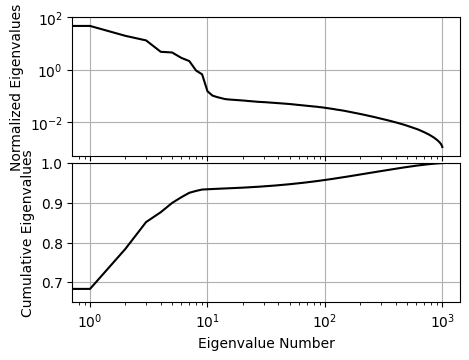

In [6]:
## now make the plot
#  because the spectra have been reconstructed from masked values, this
#  is not exactly correct in this case: we'll use the values computed
#  in the file compute_sdss_pca.py
evals = data['evals'] ** 2
evals_cs = evals.cumsum()
evals_cs /= evals_cs[-1]

#------------------------------------------------------------
# plot the eigenvalues
fig = plt.figure(figsize=(5, 3.75))
fig.subplots_adjust(hspace=0.05, bottom=0.12)

ax = fig.add_subplot(211, xscale='log', yscale='log')
ax.grid()
ax.plot(evals, c='k')
ax.set_ylabel('Normalized Eigenvalues')
ax.xaxis.set_major_formatter(plt.NullFormatter())
ax.set_ylim(5E-4, 100)

ax = fig.add_subplot(212, xscale='log')
ax.grid()
ax.semilogx(evals_cs, color='k')
ax.set_xlabel('Eigenvalue Number')
ax.set_ylabel('Cumulative Eigenvalues')
ax.set_ylim(0.65, 1.00)

plt.show()

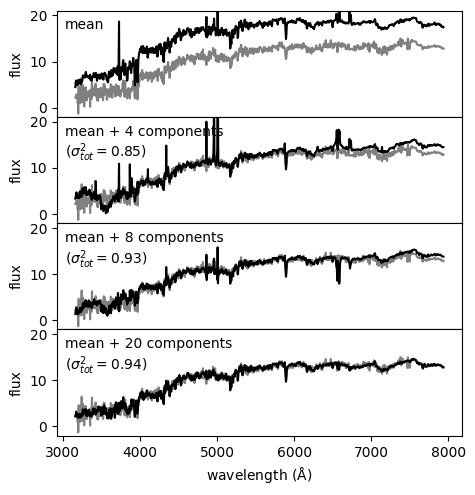

In [7]:

evecs = data['evecs']
spec_mean = spectra.mean(0)


#------------------------------------------------------------
# Find the coefficients of a particular spectrum
spec = spectra[1]
coeff = np.dot(evecs, spec - spec_mean)

#------------------------------------------------------------
# Plot the sequence of reconstructions
fig = plt.figure(figsize=(5, 5))
fig.subplots_adjust(hspace=0, top=0.95, bottom=0.1, left=0.12, right=0.93)

for i, n in enumerate([0, 4, 8, 20]):
    ax = fig.add_subplot(411 + i)
    ax.plot(wavelengths, spec, '-', c='gray')
    ax.plot(wavelengths, spec_mean + np.dot(coeff[:n], evecs[:n]), '-k')

    if i < 3:
        ax.xaxis.set_major_formatter(plt.NullFormatter())

    ax.set_ylim(-2, 21)
    ax.set_ylabel('flux')

    if n == 0:
        text = "mean"
    elif n == 1:
        text = "mean + 1 component\n"
        text += r"$(\sigma^2_{tot} = %.2f)$" % evals_cs[n - 1]
    else:
        text = "mean + %i components\n" % n
        text += r"$(\sigma^2_{tot} = %.2f)$" % evals_cs[n - 1]

    ax.text(0.02, 0.93, text, ha='left', va='top', transform=ax.transAxes)

fig.axes[-1].set_xlabel(r'${\rm wavelength\ (\AA)}$')
plt.show()

## AutoEncoder Discussion 

<img src="https://substackcdn.com/image/fetch/$s_!O-al!,f_auto,q_auto:good,fl_progressive:steep/https%3A%2F%2Fbucketeer-e05bbc84-baa3-437e-9518-adb32be77984.s3.amazonaws.com%2Fpublic%2Fimages%2F892d7242-505c-48f1-bcb0-01fbb8a0531b_2133x1600.png" width="600" height="600" alt="description" />

The basic idea here, is to create an atrifical neural network (unsuperized learning) that compresses data into a smaller dimensional subspace and then reconstructs that data.   Compression happens automatically in this "latent space" internal to the network.  Since this network is factored into the encoder, the latent space, and the decoder, there is lots of flexability to acheive different results.  For exmaple starting with the latent space you can simulate classes of objects like what is seen in the input data set.   Or you can use the encoder to compress the data to the latent space varibles.   Just like with the PCA the latent spaec varables need not be aligned with physics or human perfecption.  However, the extractor allows the physical interpereation of these variables. 


Here is a good example of compressing SDSS galaxy shapes using an autoencoder



[SDSS example](https://github.com/jwuphysics/galaxy-autoencoders?tab=readme-ov-file)